# The finite square well: leaky walls, lower energies, finite bound states
### where the quantum particle slips *into* the wall

Raise the walls of a box to a FINITE height $V_0$ and two quantum things happen that the
infinite well hides:

1. **The wavefunction leaks into the wall.** Outside the well ($E<V_0$) it decays as
   $e^{-x/\delta}$ with **penetration depth** $\delta=\hbar/\sqrt{2m(V_0-E)}$ -- the
   classically forbidden region the particle still visits.
2. **The energies drop, and there are only finitely many.** Because $\psi$ spreads past the
   walls, the well acts a bit wider, so every level sits *below* the infinite-well value, and
   a shallow well holds only a few (or one).

The bound energies aren't a tidy formula -- they solve the transcendental matching
conditions $z\tan z=\sqrt{z_0^2-z^2}$ (even) and $-z\cot z=\sqrt{z_0^2-z^2}$ (odd), where
$z=ka$ and $z_0=a\sqrt{2mV_0}/\hbar$. This notebook solves them with
`dgs/finite_square_well.py` and draws the levels, the leaky wavefunctions, and how the
penetration depth blows up for a barely-bound state. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import finite_square_well as fw
V0, a = 20.0, 1.0        # hbar = m = 1
E = fw.bound_state_energies(V0, a)
print("z0 = %.3f -> %d bound states: %s" % (fw.well_strength(V0,a), len(E), np.round(E,3)))

z0 = 6.325 -> 5 bound states: [ 0.918  3.646  8.092 14.002 19.973]


## 1. The levels: finite well (solid) vs infinite well (dashed)

Draw the well and its energy levels. Each finite-well level (solid) sits *below* the
infinite-well level (dashed) of the same width -- the gap grows for the higher states, which
lean on the soft walls more. Notice the levels are NOT evenly spaced and stop at $V_0$.

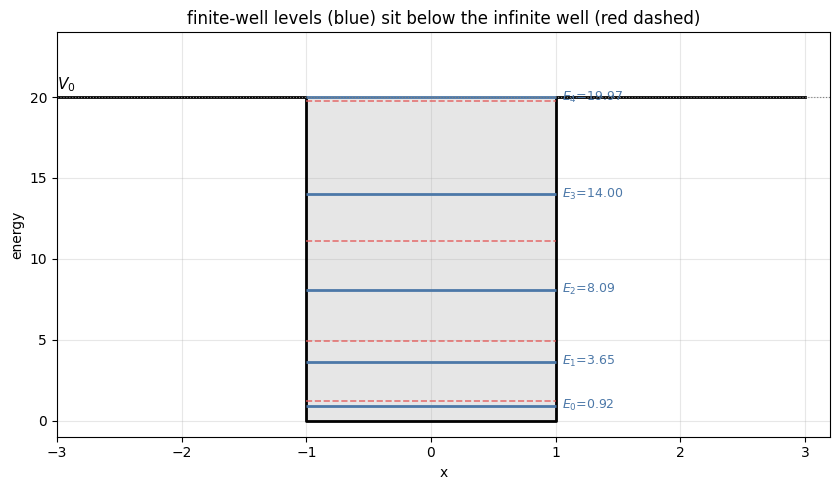

In [2]:
Einf = fw.infinite_well_energies(a, n_levels=len(E)+1)
fig, ax = plt.subplots(figsize=(8.5, 5))
# the well
ax.plot([-3*a,-a,-a,a,a,3*a], [V0,V0,0,0,V0,V0], "k", lw=2)
ax.fill_between([-a,a],[0,0],[V0,V0], color="0.9")
for n, e in enumerate(E):
    ax.hlines(e, -a, a, color="#4C78A8", lw=2)
    ax.text(a+0.05, e, f"$E_{n}$={e:.2f}", va="center", fontsize=9, color="#4C78A8")
for n, ei in enumerate(Einf[:len(E)]):
    ax.hlines(ei, -a, a, color="#E45756", lw=1.2, ls="--", alpha=0.8)
ax.axhline(V0, color="gray", lw=0.8, ls=":"); ax.text(-3*a, V0+0.5, "$V_0$", fontsize=11)
ax.set(xlim=(-3*a,3.2*a), ylim=(-1, V0+4), xlabel="x", ylabel="energy",
       title="finite-well levels (blue) sit below the infinite well (red dashed)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Leaky wavefunctions: sinusoid inside, exponential tail outside

Inside the well $\psi$ oscillates ($\cos kx$ or $\sin kx$); outside it decays as
$e^{-x/\delta}$. Reconstruct the ground and first-excited states from their $k,\kappa$ and
plot them -- the tails poking into the shaded walls are the penetration. The higher (less
bound) state has the longer tail.

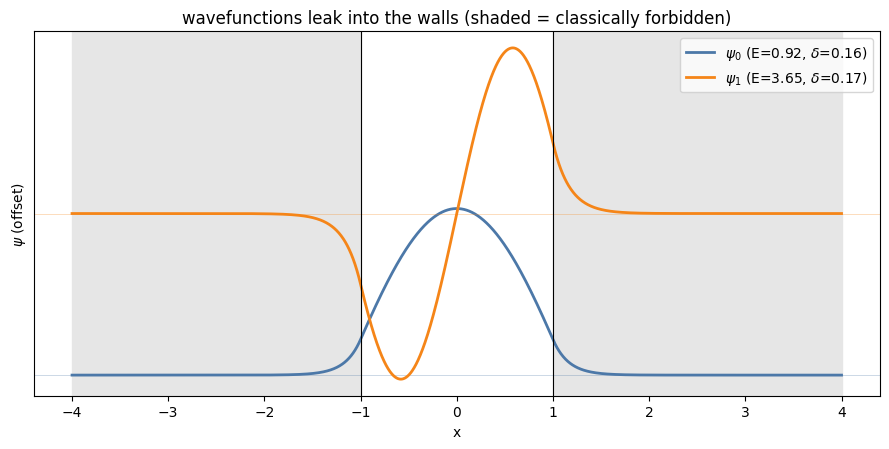

In [3]:
def wavefunction(E, V0, a, x, even=True):
    k = np.sqrt(2*E); kappa = np.sqrt(2*(V0-E))
    psi = np.where(np.abs(x) <= a,
                   (np.cos(k*x) if even else np.sin(k*x)),
                   0.0)
    edge = (np.cos(k*a) if even else np.sin(k*a))
    tail = edge * np.exp(-kappa*(np.abs(x)-a))
    if not even: tail = tail * np.sign(x)
    psi = np.where(np.abs(x) > a, tail, psi)
    return psi / np.sqrt(np.trapezoid(psi**2, x))

x = np.linspace(-4*a, 4*a, 2000)
plt.figure(figsize=(9, 4.6))
for n, (e, ev, c) in enumerate([(E[0], True, "#4C78A8"), (E[1], False, "#F58518")]):
    psi = wavefunction(e, V0, a, x, even=ev)
    plt.plot(x, psi + n*0.9, color=c, lw=2, label=f"$\\psi_{n}$ (E={e:.2f}, $\\delta$={fw.penetration_depth(e,V0):.2f})")
    plt.axhline(n*0.9, color=c, lw=0.5, alpha=0.4)
plt.axvspan(-4*a, -a, color="0.9"); plt.axvspan(a, 4*a, color="0.9")
plt.axvline(-a, color="k", lw=0.8); plt.axvline(a, color="k", lw=0.8)
plt.xlabel("x"); plt.ylabel("$\\psi$ (offset)"); plt.yticks([])
plt.title("wavefunctions leak into the walls (shaded = classically forbidden)")
plt.legend(); plt.tight_layout(); plt.show()

## 3. Penetration depth blows up as $E\to V_0$

$\delta=\hbar/\sqrt{2m(V_0-E)}$: a deeply bound state ($E\ll V_0$) barely leaks, but a state
just below the rim leaks arbitrarily far -- a particle that is *almost* free spreads far into
the wall. Plot $\delta(E)$ and mark where the actual levels fall.

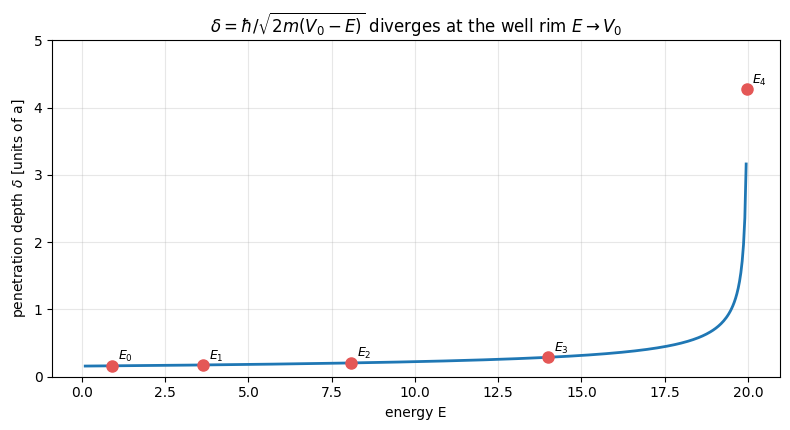

ground state leaks 0.16 a; top state leaks 4.27 a


In [4]:
Es = np.linspace(0.1, V0-0.05, 500)
plt.figure(figsize=(8, 4.4))
plt.plot(Es, [fw.penetration_depth(e, V0) for e in Es], lw=2)
for n, e in enumerate(E):
    plt.plot(e, fw.penetration_depth(e, V0), "o", ms=8, color="#E45756")
    plt.annotate(f"$E_{n}$", (e, fw.penetration_depth(e, V0)), textcoords="offset points",
                 xytext=(4,4), fontsize=9)
plt.xlabel("energy E"); plt.ylabel("penetration depth $\\delta$ [units of a]")
plt.title("$\\delta=\\hbar/\\sqrt{2m(V_0-E)}$ diverges at the well rim $E\\to V_0$")
plt.grid(alpha=0.3); plt.ylim(0, 5); plt.tight_layout(); plt.show()
print("ground state leaks %.2f a; top state leaks %.2f a"
      % (fw.penetration_depth(E[0],V0), fw.penetration_depth(E[-1],V0)))

## 4. Deeper wells hold more states -- and approach the infinite well

The count is $\lfloor z_0/(\pi/2)\rfloor+1$ with $z_0=a\sqrt{2mV_0}/\hbar$, so raising $V_0$
adds levels one at a time. And as $V_0\to\infty$ the finite levels climb up to the
infinite-well values (the leak vanishes).

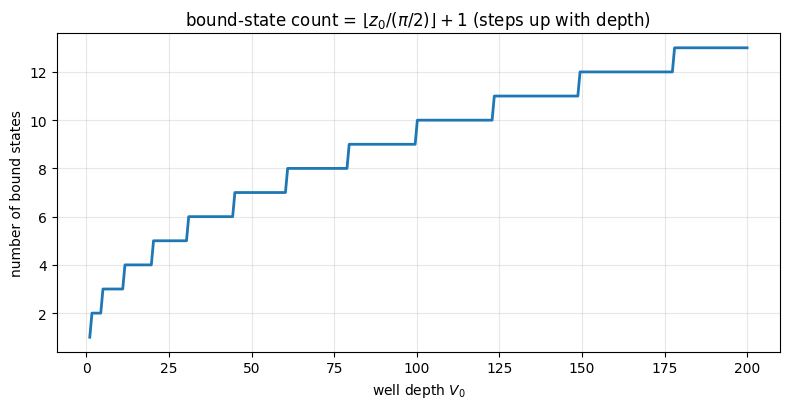

deep well V0=2000: E_0,1,2 = [ 1.196  4.782 10.76 ]  -> infinite well [ 1.234  4.935 11.103]


In [5]:
plt.figure(figsize=(8, 4.2))
V0s = np.linspace(1, 200, 300)
plt.plot(V0s, [fw.num_bound_states(v, a) for v in V0s], lw=2)
plt.xlabel("well depth $V_0$"); plt.ylabel("number of bound states")
plt.title("bound-state count = $\\lfloor z_0/(\\pi/2)\\rfloor+1$ (steps up with depth)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Ed = fw.bound_state_energies(2000.0, a); Ei = fw.infinite_well_energies(a, n_levels=3)
print("deep well V0=2000: E_0,1,2 =", np.round(Ed[:3],3), " -> infinite well", np.round(Ei,3))

## What we saw

* A finite well's wavefunction **leaks into the walls** as $e^{-x/\delta}$, with penetration
  depth $\delta=\hbar/\sqrt{2m(V_0-E)}$ that **diverges** for barely-bound states.
* Because $\psi$ spreads out, every level sits **below** the infinite-well value, and there
  are only **finitely many** ($\lfloor z_0/(\pi/2)\rfloor+1$).
* Deeper wells add states one at a time and, as $V_0\to\infty$, recover the infinite well.

Same bound-state-of-a-potential physics as `dgs/schrodinger_lennard_jones.py` and
`dgs/stability_of_matter.py` -- here with the cleanest walls that still let the particle
tunnel a little way out.